# Trabajo Práctico N°3: Redes Neuronales

In [32]:
import os

repo_url = 'https://github.com/aleorozcol/Orozco_Alejandro_TP3.git'
repo_dir = 'Orozco_Alejandro_TP3'

if not os.path.exists(repo_dir):
    print('Clonando el repositorio de Git...')
    !git clone {repo_url}
    print('Repositorio clonado con éxito.')
else:
    print('El repositorio ya existe. Obteniendo las últimas actualizaciones (git pull)...')
    %cd {repo_dir}
    !git pull
    %cd ..
    print('Repositorio actualizado con éxito.')


El repositorio ya existe. Obteniendo las últimas actualizaciones (git pull)...
/content/Orozco_Alejandro_TP3
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 336 bytes | 336.00 KiB/s, done.
From https://github.com/aleorozcol/Orozco_Alejandro_TP3
   118def4..81c5072  main       -> origin/main
Updating 118def4..81c5072
Fast-forward
 src/utils.py | 4 ++--
 1 file changed, 2 insertions(+), 2 deletions(-)
/content
Repositorio actualizado con éxito.


In [33]:
import sys
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cupy as cp
import torch
import importlib

from google.colab import drive
drive.mount('/content/drive')

# Define la ruta al directorio del repositorio Git clonado
REPO_DIR = '/content/Orozco_Alejandro_TP3/src'

# Asegura que el directorio del repositorio esté en sys.path para importaciones directas
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
    print(f"'{REPO_DIR}' añadido a sys.path.")

# Enlace simbólico 'src' para los imports internos del repositorio
if os.path.exists('src'):
    if os.path.islink('src') and os.readlink('src') != REPO_DIR:
        os.unlink('src')
        os.symlink(REPO_DIR, 'src')
        print("Enlace simbólico 'src' actualizado.")
elif not os.path.exists('src'):
    os.symlink(REPO_DIR, 'src')
    print("Enlace simbólico 'src' creado.")

# --- Importación de módulos del repositorio con importlib ---
try:
    simple = importlib.import_module('MLP_simple')
    MLP = simple.MLP
    advanced = importlib.import_module('MLP_advanced')
    metrics = importlib.import_module('metrics')
    grid_search_ = importlib.import_module('grid_search')
    pytorch = importlib.import_module('pytorch')
    utils = importlib.import_module('utils')
    data_split = importlib.import_module('data_splitting')
    print("Módulos principales del repositorio importados con éxito con importlib.")
except ImportError as e:
    print(f"Error importando módulos principales: {e}")

# Módulos opcionales
for mod_name in ['preprocessing', 'utils', 'data_splitting']:
    try:
        importlib.import_module(mod_name)
    except ImportError:
        pass

print("Módulos opcionales procesados.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Módulos principales del repositorio importados con éxito con importlib.
Módulos opcionales procesados.


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Análisis y Preprocesamiento de Datos

In [5]:
X_images = np.load("X_images.npy")
y_images = np.load("y_images.npy")
print(f"Datos cargados: X_images {X_images.shape}, y_images {y_images.shape}")

Datos cargados: X_images (809555, 28, 28), y_images (809555,)


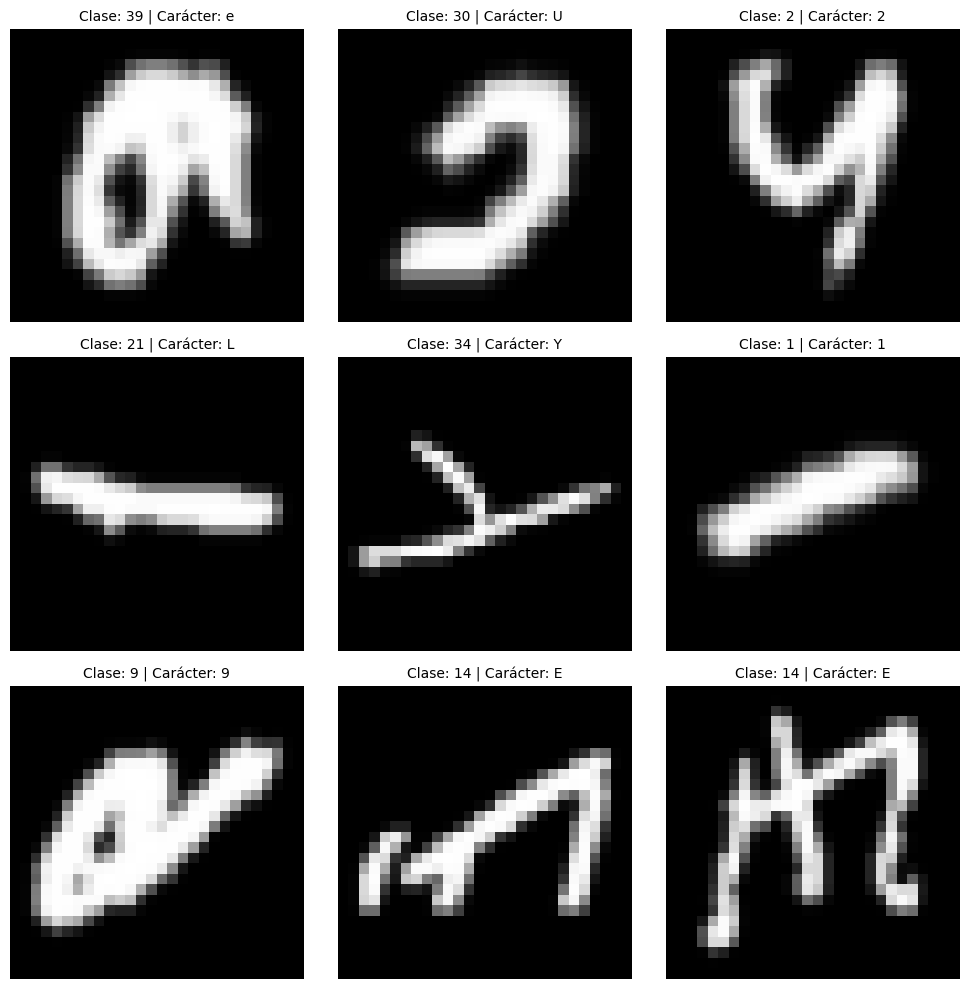

In [6]:
utils.plot_random_emnist_samples(X_images, y_images, n_samples=9)

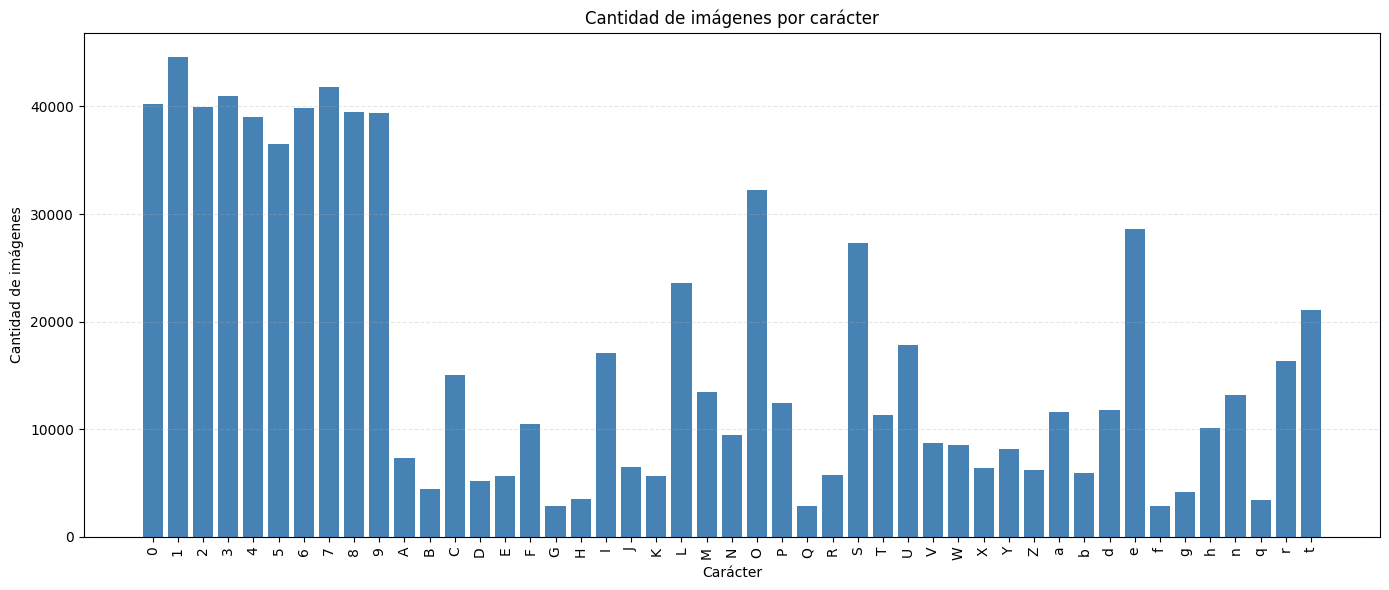

In [7]:
utils.plot_emnist_character_distribution(y_images)

In [8]:
X_train_norm, y_train, X_val_norm, y_val, X_test_norm, y_test = data_split.split_train_val_test_and_normalize(X_images, y_images, seed=42)

print(f"Tamaño Train: {X_train_norm.shape[0]} muestras")
print(f"Tamaño Validación: {X_val_norm.shape[0]} muestras")
print(f"Tamaño Test: {X_test_norm.shape[0]} muestras")
print(f"Rango de datos normalizados: Min={X_train_norm.min()}, Max={X_train_norm.max()}")

Tamaño Train: 566688 muestras
Tamaño Validación: 121433 muestras
Tamaño Test: 121434 muestras
Rango de datos normalizados: Min=0.0, Max=1.0


## 2. Implementación y Entrenamiento de una Red Neuronal Básica

In [40]:
# Aplanamos las imágenes. La red MLP espera vectores 1D como entrada,
# por lo que pasamos de (N, 28, 28) a (N, 784)
X_train_flat = X_train_norm.reshape(X_train_norm.shape[0], -1)
X_val_flat = X_val_norm.reshape(X_val_norm.shape[0], -1)
X_test_flat = X_test_norm.reshape(X_test_norm.shape[0], -1)

In [10]:
# Entrada: 784 nodos (28x28)
# Capas ocultas: 128 y 64 nodos
# Salida: 47 nodos (clases de EMNIST)
architecture_M0 = [784, 128, 64, 47]

M0 = MLP(architecture_M0)

EPOCHS = 100
LEARNING_RATE = 0.1

print("Iniciando entrenamiento del modelo M0...")
train_loss_M0, val_loss_M0 = M0.train(X_train_flat, y_train, X_val_flat, y_val, EPOCHS, LEARNING_RATE)

Iniciando entrenamiento del modelo M0...
Época 000 | Train Loss: 4.0399 | Val Loss: 3.9180
Época 010 | Train Loss: 3.4971 | Val Loss: 3.4562
Época 020 | Train Loss: 3.0601 | Val Loss: 3.0267
Época 030 | Train Loss: 2.7121 | Val Loss: 2.6887
Época 040 | Train Loss: 2.4407 | Val Loss: 2.4234
Época 050 | Train Loss: 2.2224 | Val Loss: 2.2088
Época 060 | Train Loss: 2.0447 | Val Loss: 2.0340
Época 070 | Train Loss: 1.9010 | Val Loss: 1.8925
Época 080 | Train Loss: 1.7847 | Val Loss: 1.7779
Época 090 | Train Loss: 1.6907 | Val Loss: 1.6866
Época 099 | Train Loss: 1.7024 | Val Loss: 1.6958


## Explicación de la implementación del Punto 2

La red neuronal usada en este punto es un **MLP (Multilayer Perceptron)** totalmente conectado. En el notebook se crea con `arquitectura_M0 = [784, 128, 64, 47]`, y eso significa lo siguiente:

- **784 nodos de entrada**: cada imagen de 28x28 píxeles se aplana con `reshape` para transformarse en un vector de 784 valores.
- **2 capas ocultas**: la primera con 128 neuronas y la segunda con 64 neuronas.
- **47 nodos de salida**: uno por cada clase del dataset EMNIST.

### 1. Entrada de los datos
Antes de entrenar, las imágenes se normalizan y luego se convierten de matriz a vector. Esto permite que la red reciba una fila por muestra, algo necesario para trabajar con capas densas. Cada vector representa la imagen completa en una sola dimensión.

### 2. Inicialización de pesos y sesgos
En la clase `MLP`, cada capa aprende dos parámetros:

- **Pesos (`W`)**: controlan la fuerza de la conexión entre neuronas.
- **Sesgos (`b`)**: permiten desplazar la activación de cada neurona.

Los pesos se inicializan con una estrategia tipo **He initialization**, que ayuda a mantener estables las activaciones al comienzo del entrenamiento y evita que la señal se apague o explote en redes con ReLU.

### 3. Forward pass
En cada capa oculta la red calcula:

$$Z = A \cdot W + b$$

Luego aplica la función **ReLU**:

$$\mathrm{ReLU}(Z) = \max(0, Z)$$

Esto introduce no linealidad, lo que permite que la red aprenda patrones complejos. Si no se usara una activación como ReLU, la red se comportaría como una transformación lineal apilada y perdería capacidad de representación.

### 4. Capa de salida
La última capa no usa ReLU, sino **softmax**. Primero genera los logits finales y después los transforma en probabilidades para las 47 clases.

La softmax convierte los valores de salida en una distribución de probabilidad, de modo que todas las probabilidades sumen 1. En la implementación se resta el máximo de cada fila antes de exponentiar para mejorar la estabilidad numérica.

### 5. Función de pérdida
El entrenamiento usa **cross-entropy**, que compara las probabilidades predichas con las etiquetas reales en formato one-hot. Esta pérdida penaliza más cuando la red asigna baja probabilidad a la clase correcta.

### 6. Backpropagation
Durante el retroceso del error, la red calcula cómo cambia la pérdida respecto de cada peso y sesgo. En la salida, la combinación **softmax + cross-entropy** simplifica el gradiente a:

$$dZ = \hat{Y} - Y$$

#### Demostración matemática del gradiente en la salida:
Para un único ejemplo de entrenamiento, definimos:
* $z_i$: Entrada lineal (logit) para la clase $i$.
* $\hat{y}_i$: Probabilidad predicha por la función Softmax para la clase $i$, donde $\hat{y}_i = \frac{e^{z_i}}{\sum_{k=1}^K e^{z_k}}$.
* $y_i$: Etiqueta real en formato *one-hot encoding* ($y_i = 1$ para la clase correcta, $0$ para las demás).
* $\mathcal{L}$: Función de costo Cross-Entropy, donde $\mathcal{L} = -\sum_{k=1}^K y_k \log(\hat{y}_k)$.

Queremos calcular la derivada parcial del costo respecto a cada logit ($\frac{\partial \mathcal{L}}{\partial z_i}$). Aplicando la regla de la cadena multivariable, la ecuación se expande considerando que un cambio en $z_i$ afecta a todas las predicciones de la salida:

$$\frac{\partial \mathcal{L}}{\partial z_i} = \sum_{j=1}^K \frac{\partial \mathcal{L}}{\partial \hat{y}_j} \frac{\partial \hat{y}_j}{\partial z_i}$$

**Paso 1: Derivada de la pérdida respecto a las predicciones ($\frac{\partial \mathcal{L}}{\partial \hat{y}_j}$)**
Al derivar la sumatoria de Cross-Entropy respecto a una componente específica $\hat{y}_j$, el único término que sobrevive es el correspondiente al índice $j$:
$$\frac{\partial \mathcal{L}}{\partial \hat{y}_j} = -\frac{y_j}{\hat{y}_j}$$

**Paso 2: Derivada de Softmax respecto a los logits ($\frac{\partial \hat{y}_j}{\partial z_i}$)**
Utilizando la regla del cociente para la función Softmax, se desprenden dos casos:
* Si $i = j$ (misma clase):
$$\frac{\partial \hat{y}_i}{\partial z_i} = \hat{y}_i(1 - \hat{y}_i)$$
* Si $i \neq j$ (clases distintas):
$$\frac{\partial \hat{y}_j}{\partial z_i} = -\hat{y}_j\hat{y}_i$$

**Paso 3: Combinación mediante la Regla de la Cadena**
Separamos la sumatoria original aislando el caso donde el índice de la derivada coincide con el de la predicción ($j = i$):

$$\frac{\partial \mathcal{L}}{\partial z_i} = \left( \frac{\partial \mathcal{L}}{\partial \hat{y}_i} \frac{\partial \hat{y}_i}{\partial z_i} \right) + \sum_{j \neq i}^K \left( \frac{\partial \mathcal{L}}{\partial \hat{y}_j} \frac{\partial \hat{y}_j}{\partial z_i} \right)$$

Sustituyendo los resultados de los pasos anteriores:

$$\frac{\partial \mathcal{L}}{\partial z_i} = \left( -\frac{y_i}{\hat{y}_i} \right) \left( \hat{y}_i(1 - \hat{y}_i) \right) + \sum_{j \neq i}^K \left( -\frac{y_j}{\hat{y}_j} \right) \left( -\hat{y}_j\hat{y}_i \right)$$

Simplificando los términos algebraicamente:

$$\frac{\partial \mathcal{L}}{\partial z_i} = -y_i(1 - \hat{y}_i) + \sum_{j \neq i}^K y_j\hat{y}_i$$

$$\frac{\partial \mathcal{L}}{\partial z_i} = -y_i + y_i\hat{y}_i + \sum_{j \neq i}^K y_j\hat{y}_i$$

Factorizando el término común $\hat{y}_i$:

$$\frac{\partial \mathcal{L}}{\partial z_i} = -y_i + \hat{y}_i \left( y_i + \sum_{j \neq i}^K y_j \right)$$

Dado que el vector de etiquetas reales $Y$ utiliza codificación *one-hot*, la suma de todas sus componentes es estrictamente igual a 1 ($\sum_{k=1}^K y_k = 1$). Por lo tanto, la expresión entre paréntesis se simplifica a la unidad:

$$\frac{\partial \mathcal{L}}{\partial z_i} = \hat{y}_i - y_i$$

Extendiendo este resultado a su representación matricial para todo el conjunto de datos, obtenemos la simplificación del gradiente de la capa de salida:

$$dZ = \hat{Y} - Y$$

Después ese error se propaga hacia atrás capa por capa usando la regla de la cadena. En las capas ocultas se multiplica por la derivada de ReLU, que vale 1 cuando la activación fue positiva y 0 cuando fue negativa.

### 7. Actualización de parámetros
Con los gradientes ya calculados, la red actualiza pesos y sesgos con descenso por gradiente:

$$\theta := \theta - \alpha \cdot \nabla\theta$$

donde `\alpha` es el **learning rate**. En este caso, el entrenamiento del modelo base usa `LEARNING_RATE = 0.1` y `EPOCHS = 100`.

### 8. Resumen del flujo completo
En cada época ocurre esta secuencia:

1. Se hace un **forward pass** con las imágenes de entrenamiento.
2. Se calcula la **loss**.
3. Se ejecuta **backpropagation**.
4. Se actualizan los parámetros.
5. Se evalúa el modelo en validación sin modificar los pesos.

En resumen, el punto 2 implementa una red densa clásica: recibe la imagen ya aplanada, aprende representaciones intermedias con ReLU, produce probabilidades con softmax y ajusta sus parámetros mediante cross-entropy y descenso por gradiente.

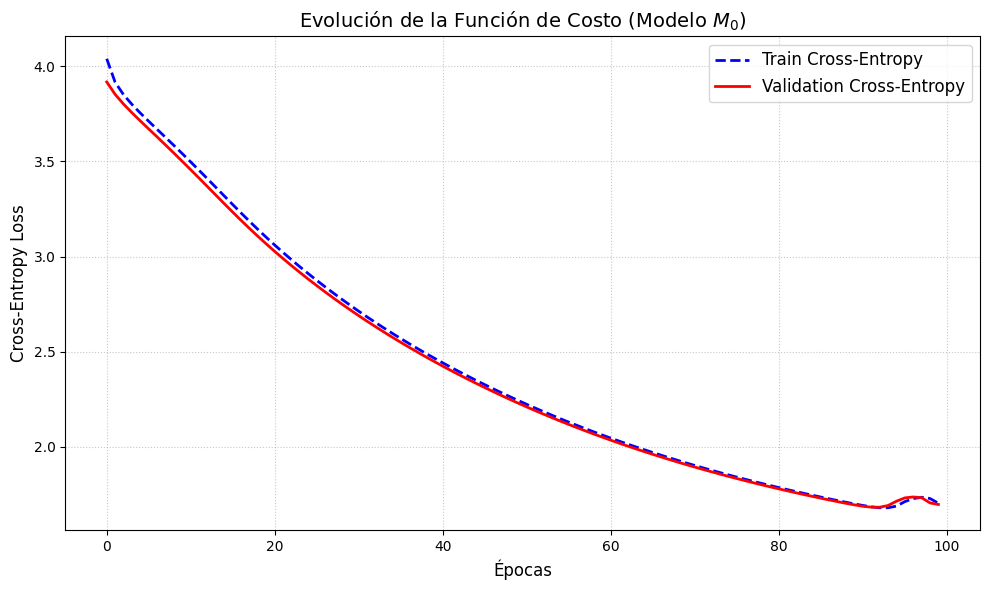

In [11]:
utils.plot_loss_curves(
    train_loss_M0,
    val_loss_M0,
    title='Evolución de la Función de Costo (Modelo $M_0$)'
)

In [12]:
metrics_m0 = metrics.build_metrics_report(
    M0,
    X_train_flat,
    y_train,
    X_val_flat,
    y_val,
    num_classes=47,
    model_name='M0'
)

metrics_m0[['Train', 'Validation']] = metrics_m0[['Train', 'Validation']].round(4)
metrics_m0

,Métrica,Train,Validation,Modelo
0,Cross-Entropy,1.6918,1.6958,M0
1,Accuracy,0.5664,0.5641,M0
2,F1-Score Macro,0.3389,0.3382,M0


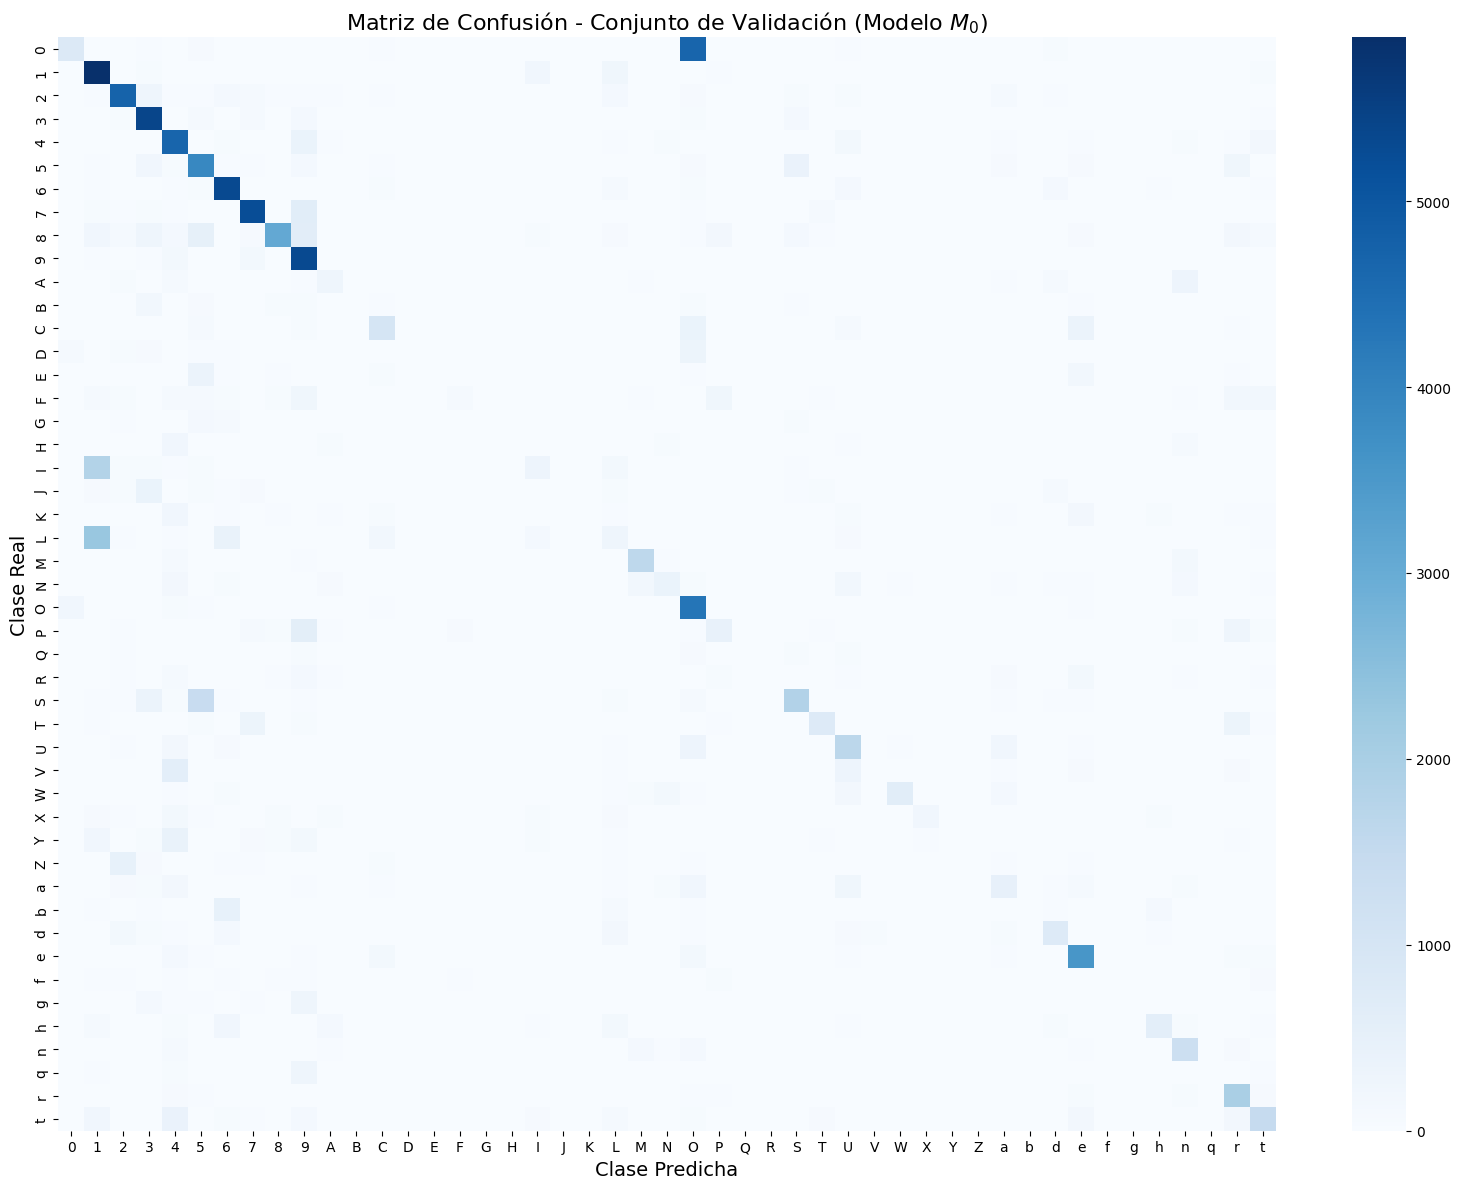

In [13]:
y_pred_val = metrics.predict(M0, X_val_flat)
cm_val = metrics.compute_confusion_matrix(y_val, y_pred_val, num_classes=47)

utils.plot_confusion_matrix_with_characters(
    cm_val,
    title='Matriz de Confusión - Conjunto de Validación (Modelo $M_0$)'
)

## 3. Implementación y Entrenamiento de una Red Neuronal Avanzada

## Fundamento teórico de las mejoras

Las mejoras agregadas al entrenamiento buscan reducir el error de validación, acelerar la convergencia y mejorar la capacidad de generalización del modelo. La idea central es no entrenar la red siempre de la misma forma, sino adaptar el proceso de optimización y la complejidad de la arquitectura para que el aprendizaje sea más estable.

### Rate scheduling
El *learning rate* controla el tamaño del paso que da el optimizador en cada actualización. Si es muy alto, el entrenamiento puede oscilar o divergir; si es muy bajo, el modelo aprende muy lento. Por eso se usan esquemas de *rate scheduling*:

- **Exponencial**: disminuye el learning rate de forma progresiva. Al principio permite pasos grandes para avanzar rápido y luego pasos más chicos para refinar la solución.
- **Lineal con saturación**: reduce el learning rate de manera uniforme hasta un mínimo fijo. La saturación evita que el valor siga cayendo indefinidamente y permite conservar una tasa estable al final.

### Mini-batch stochastic gradient descent
En vez de actualizar los pesos con todo el conjunto de entrenamiento a la vez, se usan subconjuntos pequeños llamados *mini-batches*. Esto introduce una estimación ruidosa del gradiente que, aunque menos exacta, suele ser más eficiente computacionalmente y puede ayudar a escapar de mínimos pobres o mesetas. Además, permite combinar buena velocidad de entrenamiento con actualizaciones más frecuentes que el batch completo.

### Optimizador Adam
Adam combina ideas de *momentum* y de adaptación por parámetro. No solo usa el gradiente actual, sino también promedios móviles de los gradientes y de sus cuadrados. En la práctica, esto hace que cada peso tenga un paso ajustado a la escala de su propio historial de gradientes. Suele converger más rápido y ser menos sensible a la elección inicial del learning rate que SGD puro.

### Regularización L2
L2 agrega una penalización proporcional a la suma de los cuadrados de los pesos. El efecto teórico es forzar a la red a preferir soluciones con pesos más pequeños, lo que reduce la complejidad efectiva del modelo y ayuda a disminuir el sobreajuste. En lugar de memorizar el entrenamiento, la red tiende a aprender representaciones más suaves y estables.

### Early stopping
Early stopping detiene el entrenamiento cuando la pérdida de validación deja de mejorar. Su justificación teórica es que, a partir de cierto punto, seguir entrenando puede mejorar el ajuste sobre entrenamiento pero empeorar la generalización. Entonces se usa la validación como criterio de parada para conservar el punto donde el modelo generaliza mejor.

### Cambios en la arquitectura
Modificar la cantidad de capas ocultas y neuronas cambia la capacidad representacional de la red. Una red más pequeña puede quedarse corta (*underfitting*), mientras que una muy grande o muy profunda puede aprender patrones demasiado específicos del entrenamiento (*overfitting*). Por eso conviene explorar arquitecturas distintas y elegir la que minimice el error de validación.

En conjunto, todas estas mejoras apuntan a equilibrar tres cosas: velocidad de entrenamiento, estabilidad de la optimización y capacidad de generalización.

## Explicación de la implementación del Punto 3

En este punto se implementa una versión más completa de la red neuronal, llamada `MLP_Advanced`, y se usa una **búsqueda exhaustiva de hiperparámetros** para encontrar la mejor configuración posible sobre el conjunto de validación.

### 1. Qué se busca optimizar
La idea del grid search es probar varias combinaciones de arquitectura y parámetros de entrenamiento para comparar su rendimiento. En tu caso se exploran estas decisiones:

- **Arquitectura**: se prueban dos variantes, una red más ancha `[784, 256, 128, 47]` y una más profunda `[784, 128, 64, 32, 47]`.
- **Optimizador**: se comparan `sgd` y `adam`.
- **Learning rate**: se fija en `0.01` para todas las pruebas.
- **Batch size**: se prueban `128` y `256`.
- **Regularización L2**: se compara sin regularización (`0.0`) y con regularización (`0.01`).

### 2. Cómo se generan las combinaciones
En `grid_search.py` se arma un diccionario `param_grid` con todas las opciones y luego se usa `itertools.product` para construir las combinaciones posibles. Eso permite evaluar cada configuración de forma sistemática, sin elegir parámetros al azar.

Como resultado, se prueban **16 configuraciones** en total. Cada una combina arquitectura, optimizador, batch size y L2.

### 3. Qué hace `MLP_Advanced`
Esta clase mantiene la estructura de una red totalmente conectada, pero agrega mejoras importantes respecto del modelo base:

- **Inicialización de He** para los pesos, igual que en el modelo anterior.
- **ReLU** en las capas ocultas para introducir no linealidad.
- **Softmax** en la salida para obtener probabilidades por clase.
- **Cross-entropy con L2** para penalizar errores y evitar pesos demasiado grandes.
- **Adam o SGD** como estrategias de actualización.

### 4. Cómo entrena cada configuración
Para cada combinación, se crea una red nueva desde cero. Después se entrena con la función `train`, que hace lo siguiente en cada época:

1. Mezcla los datos de entrenamiento.
2. Divide el conjunto en mini-batches según el `batch_size`.
3. Ejecuta el forward pass.
4. Calcula la pérdida con cross-entropy y el término L2.
5. Aplica backpropagation.
6. Actualiza los pesos con SGD o Adam.
7. Evalúa la red en validación.

Además, se usa **learning rate scheduling exponencial**, que reduce progresivamente la tasa de aprendizaje durante el entrenamiento. Esto ayuda a que el modelo haga pasos grandes al principio y ajustes más finos al final.

### 5. Early stopping
La red también incorpora **early stopping**: si la validación no mejora durante varias épocas consecutivas, el entrenamiento se interrumpe antes de llegar al máximo de épocas. Esto evita sobreentrenar configuraciones malas y ahorra tiempo de cómputo.

### 6. Cómo se elige el mejor modelo
Para comparar configuraciones, se toma la **mínima validation loss** obtenida por cada una. La mejor configuración es la que logra el menor valor de pérdida en validación, porque es la que generaliza mejor sobre datos no vistos.

En tu ejecución, esa búsqueda selecciona como ganadora la arquitectura `[784, 256, 128, 47]` con `adam`, `learning_rate = 0.01`, `batch_size = 256` y `l2 = 0.01`. Luego esa configuración se guarda en `M1_config` para reutilizarla en el entrenamiento final.

### 7. Qué muestran los resultados
Después del grid search, se construyen dos resúmenes:

- `top_5_results`, con las cinco mejores configuraciones ordenadas por validation loss.
- `all_16_configs`, con todas las combinaciones evaluadas y su desempeño.

De esta forma, el punto 3 no solo entrena una red más robusta, sino que también justifica la elección de hiperparámetros con una comparación objetiva entre varias alternativas.

### 8. Verificación contra la consigna
Sí, la implementación cumple con lo pedido en la consigna:

- **Rate scheduling lineal y exponencial**: están implementados en `MLP_Advanced.train`. La variante exponencial es la que se usa en el entrenamiento final de M1 (`scheduler_type='exponential'`), y la lineal queda disponible con `scheduler_type='linear'`.
- **Mini-batch stochastic gradient descent**: se activa cuando `batch_size` vale `128` o `256`; en cada época se barajan los datos y se entrenan mini-lotes en vez de usar todo el conjunto de una sola vez.
- **Optimizador Adam**: se implementa en `update_params` y se compara contra SGD dentro del grid search.
- **Regularización L2 y Early Stopping**: ambas están integradas en `compute_loss`, `backward` y `train`.

### 9. Efecto observado en tus resultados
- **Adam vs SGD**: con la misma arquitectura `[784, 256, 128, 47]`, `batch_size = 128` y `l2 = 0.01`, Adam logra `Val Loss = 0.3502` frente a `0.3898` de SGD, aunque tarda más (`1689.1 s` vs `1334.7 s`).
- **Mini-batch**: al pasar de entrenamiento full-batch en M0 a mini-batches en M1, la validación mejora de forma muy marcada. El mejor M1 baja a `Val Loss = 0.3313`, muy por debajo del M0 final (`1.6144`).
- **Arquitectura**: la red `[784, 256, 128, 47]` rindió mejor que la versión más profunda `[784, 128, 64, 32, 47]`. La profunda fue más rápida (`779.3 s`) pero peor en validación (`0.3622`).
- **L2**: con la misma arquitectura, Adam y `batch_size = 256`, agregar L2 mejora la validación (`0.3313` con L2 vs `0.4041` sin L2), aunque el entrenamiento tarda más porque la red sigue aprendiendo hasta una mejor zona antes de detenerse.
- **Early Stopping**: se activa cuando la validación deja de mejorar durante `patience` épocas. En tus corridas se ve que corta antes del máximo configurado, por ejemplo en las épocas 28 y 34, reduciendo tiempo inútil de entrenamiento.

### 10. Nota sobre el scheduling lineal
La variante lineal con saturación está programada y lista para usarse, pero en esta corrida concreta del notebook el reporte visible corresponde al scheduling exponencial porque es el que se dejó activo para M1.

Época 000 | [Exp] LR: 0.10000 | Train Loss: 0.8984 | Val Loss: 0.6409
Época 005 | [Exp] LR: 0.07788 | Train Loss: 0.4070 | Val Loss: 0.4120
Época 010 | [Exp] LR: 0.06065 | Train Loss: 0.3652 | Val Loss: 0.3885
Época 015 | [Exp] LR: 0.04724 | Train Loss: 0.3451 | Val Loss: 0.3799
Época 019 | [Exp] LR: 0.03867 | Train Loss: 0.3352 | Val Loss: 0.3719
Época 000 | [Exp] LR: 0.10000 | Train Loss: 4.0149 | Val Loss: 42.3031
Época 005 | [Exp] LR: 0.07788 | Train Loss: 7.0623 | Val Loss: 4.6195
Época 010 | [Exp] LR: 0.06065 | Train Loss: 3.7772 | Val Loss: 3.7505
Época 015 | [Exp] LR: 0.04724 | Train Loss: 3.7105 | Val Loss: 3.7033
Época 019 | [Exp] LR: 0.03867 | Train Loss: 3.6759 | Val Loss: 3.6713
Época 000 | [Lin] LR: 0.10000 | Train Loss: 3.9137 | Val Loss: 3.8141
Época 005 | [Lin] LR: 0.07369 | Train Loss: 3.6222 | Val Loss: 3.5879
Época 010 | [Lin] LR: 0.04737 | Train Loss: 3.4734 | Val Loss: 3.4524
Época 015 | [Lin] LR: 0.02106 | Train Loss: 3.3857 | Val Loss: 3.3772
Época 019 | [Lin] L

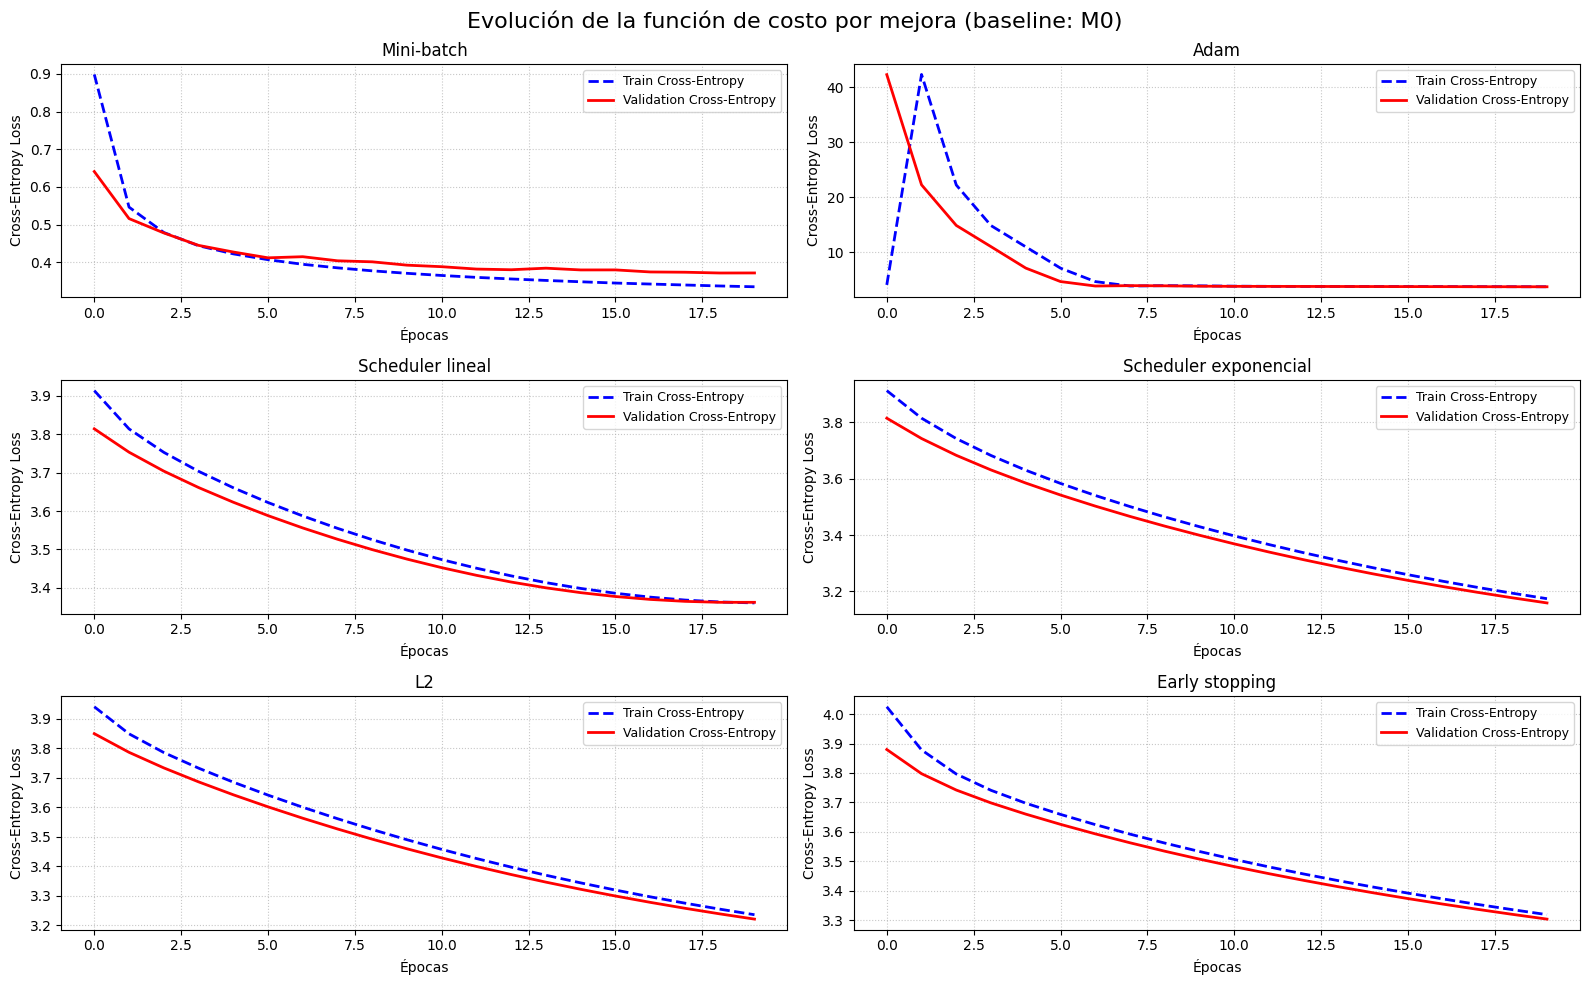

,Experimento,Scheduler,Batch Size,Optimizer,L2,Patience,Épocas ejecutadas,Tiempo (s),Train Loss,Val Loss,Train Acc,Val Acc,Train F1,Val F1,ΔTiempo vs M0 (%),ΔVal Loss vs M0 (%)
0,M0,sgd,Full,sgd,0.00,-,NaN,NaN,1.7024,1.6958,0.5664,0.5641,0.3389,0.3382,NaN,0.0000
1,Mini-batch,exponential,256,sgd,0.00,5,20.0,86.8205,0.3352,0.3719,0.8840,0.8723,0.8526,0.8366,NaN,-78.0713
2,Adam,exponential,Full,adam,0.00,5,20.0,48.3648,3.6759,3.6713,0.0554,0.0549,0.0027,0.0026,NaN,116.4909
3,Scheduler lineal,linear,Full,sgd,0.00,5,20.0,48.3941,3.3605,3.3621,0.2383,0.2384,0.0740,0.0741,NaN,98.2575
4,Scheduler exponencial,exponential,Full,sgd,0.00,5,20.0,48.3892,3.1741,3.1590,0.2543,0.2529,0.0812,0.0811,NaN,86.2785
5,L2,exponential,Full,sgd,0.01,5,20.0,48.3638,3.2361,3.2213,0.2383,0.2351,0.0709,0.0702,NaN,89.9522
6,Early stopping,exponential,Full,sgd,0.00,5,20.0,48.3779,3.3183,3.3032,0.1921,0.1903,0.0754,0.0751,NaN,94.7820


In [ ]:
# Ablation study sobre M0
X_train_gpu = cp.asarray(X_train_flat)
X_val_gpu = cp.asarray(X_val_flat)
y_train_gpu = cp.asarray(y_train)
y_val_gpu = cp.asarray(y_val)

baseline_metrics_m0 = metrics_m0.set_index('Métrica')
reference_metrics_m0 = {
    'Train Loss': float(train_loss_M0[-1]),
    'Val Loss': float(val_loss_M0[-1]),
    'Train Acc': float(baseline_metrics_m0.loc['Accuracy', 'Train']),
    'Val Acc': float(baseline_metrics_m0.loc['Accuracy', 'Validation']),
    'Train F1': float(baseline_metrics_m0.loc['F1-Score Macro', 'Train']),
    'Val F1': float(baseline_metrics_m0.loc['F1-Score Macro', 'Validation']),
    'Scheduler': 'sgd',
    'Batch Size': 'Full',
    'Optimizer': 'sgd',
    'L2': 0.0,
    'Patience': '-'
}

improvement_experiments = [
    {'name': 'Mini-batch', 'scheduler_type': 'exponential', 'batch_size': 256, 'optimizer': 'sgd', 'l2': 0.0, 'patience': 5},
    {'name': 'Adam', 'scheduler_type': 'exponential', 'batch_size': None, 'optimizer': 'adam', 'l2': 0.0, 'patience': 5},
    {'name': 'Scheduler lineal', 'scheduler_type': 'linear', 'batch_size': None, 'optimizer': 'sgd', 'l2': 0.0, 'patience': 5},
    {'name': 'Scheduler exponencial', 'scheduler_type': 'exponential', 'batch_size': None, 'optimizer': 'sgd', 'l2': 0.0, 'patience': 5},
    {'name': 'L2', 'scheduler_type': 'exponential', 'batch_size': None, 'optimizer': 'sgd', 'l2': 0.01, 'patience': 5},
    {'name': 'Early stopping', 'scheduler_type': 'exponential', 'batch_size': None, 'optimizer': 'sgd', 'l2': 0.0, 'patience': 5},
]

ablation_df, ablation_histories = metrics.compare_training_improvements(
    model_factory=lambda: advanced.MLP_Advanced([784, 128, 64, 47]),
    experiments=improvement_experiments,
    X_train=X_train_gpu,
    y_train=y_train_gpu,
    X_val=X_val_gpu,
    y_val=y_val_gpu,
    reference_metrics=reference_metrics_m0,
    epochs=20,
    learning_rate=0.1,
    num_classes=47,
    reference_name='M0',
    return_histories=True,
)

utils.plot_ablation_loss_curves(val_loss_M0, ablation_histories, baseline_name='M0')

ablation_df.round(4)

In [15]:
M1_config, historial_grid, df_top5 = grid_search_.grid_search(
    X_train_gpu, y_train_gpu, X_val_gpu, y_val_gpu,
    epochs=40,
    patience=5
)

Iniciando Grid Search. Total de configuraciones a probar: 1
------------------------------------------------------------

[1/1] Probando: Opt=adam, LR=0.001, L2=0.01, Batch=128, Arq=[784, 256, 128, 47]
Época 000 | [Exp] LR: 0.00100 | Train Loss: 0.6027 | Val Loss: 0.4199
Época 005 | [Exp] LR: 0.00078 | Train Loss: 0.3721 | Val Loss: 0.3381
Época 010 | [Exp] LR: 0.00061 | Train Loss: 0.3438 | Val Loss: 0.3176
Época 015 | [Exp] LR: 0.00047 | Train Loss: 0.3259 | Val Loss: 0.3128
Época 020 | [Exp] LR: 0.00037 | Train Loss: 0.3131 | Val Loss: 0.3053
Época 025 | [Exp] LR: 0.00029 | Train Loss: 0.3031 | Val Loss: 0.3049
Época 030 | [Exp] LR: 0.00022 | Train Loss: 0.2949 | Val Loss: 0.3010
Época 035 | [Exp] LR: 0.00017 | Train Loss: 0.2884 | Val Loss: 0.2995
Época 039 | [Exp] LR: 0.00014 | Train Loss: 0.2839 | Val Loss: 0.3004
--> Val Loss: 0.2990 | Tiempo: 589.3 seg
⭐ ¡NUEVO MEJOR MODELO ENCONTRADO!

                             RESUMEN FINAL DEL GRID SEARCH                              
Mej

In [ ]:
print("Iniciando entrenamiento del modelo M1...")

M1 = advanced.MLP_Advanced(M1_config['arquitectura'])

t_start = time.time()
train_loss_m1_gpu, val_loss_m1_gpu = M1.train(
    X_train_gpu, y_train_gpu, X_val_gpu, y_val_gpu,
    epochs=100,
    learning_rate=M1_config['learning_rate'],
    batch_size=M1_config['batch_size'],
    optimizer=M1_config['optimizer'],
    l2=M1_config['l2'],
    patience=5,
    scheduler_type='exponential',
    decay_rate=0.05,
    final_lr=1e-5
)
t_m1 = time.time() - t_start

train_loss_M1 = np.array([float(x) for x in train_loss_m1_gpu])
val_loss_M1 = np.array([float(x) for x in val_loss_m1_gpu])

print(f"\nM1 entrenado en {t_m1:.1f} segundos")
print(f"  • Loss Train Final: {train_loss_M1[-1]:.4f}")
print(f"  • Loss Val Final: {val_loss_M1[-1]:.4f}")


Iniciando entrenamiento del modelo M1...
Época 000 | [Exp] LR: 0.00100 | Train Loss: 0.6067 | Val Loss: 0.4144
Época 005 | [Exp] LR: 0.00078 | Train Loss: 0.3726 | Val Loss: 0.3357
Época 010 | [Exp] LR: 0.00061 | Train Loss: 0.3448 | Val Loss: 0.3237
Época 015 | [Exp] LR: 0.00047 | Train Loss: 0.3271 | Val Loss: 0.3109
Época 020 | [Exp] LR: 0.00037 | Train Loss: 0.3142 | Val Loss: 0.3040
Época 025 | [Exp] LR: 0.00029 | Train Loss: 0.3036 | Val Loss: 0.3034
Época 030 | [Exp] LR: 0.00022 | Train Loss: 0.2955 | Val Loss: 0.2994
Época 035 | [Exp] LR: 0.00017 | Train Loss: 0.2888 | Val Loss: 0.3003

¡Early stopping en la época 35!

M1 entrenado en 528.7 segundos
  • Loss Train Final: 0.2888
  • Loss Val Final: 0.3003
  • Mejora vs M0: -82.29%


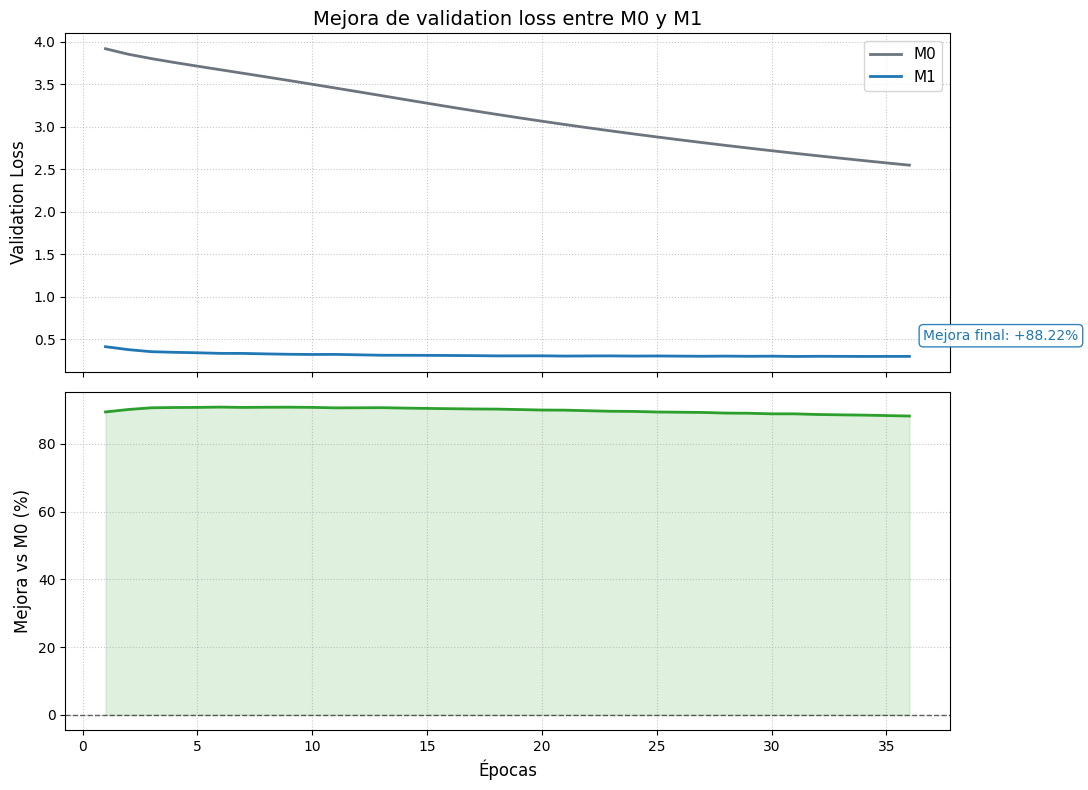

In [22]:
# Comparar visualmente la mejora de validation loss entre M0 y M1
importlib.reload(utils)
utils.plot_validation_loss_improvement(
    val_loss_M0,
    val_loss_M1,
    baseline_label='M0',
    improved_label='M1',
)

,Métrica,M0,M1,Cambio absoluto,Cambio % vs M0
0,Cross-Entropy,1.6958,0.3002,-1.3956,-82.30
1,Accuracy,0.5641,0.8921,0.3280,58.15
2,F1-Score Macro,0.3382,0.8678,0.5296,156.59


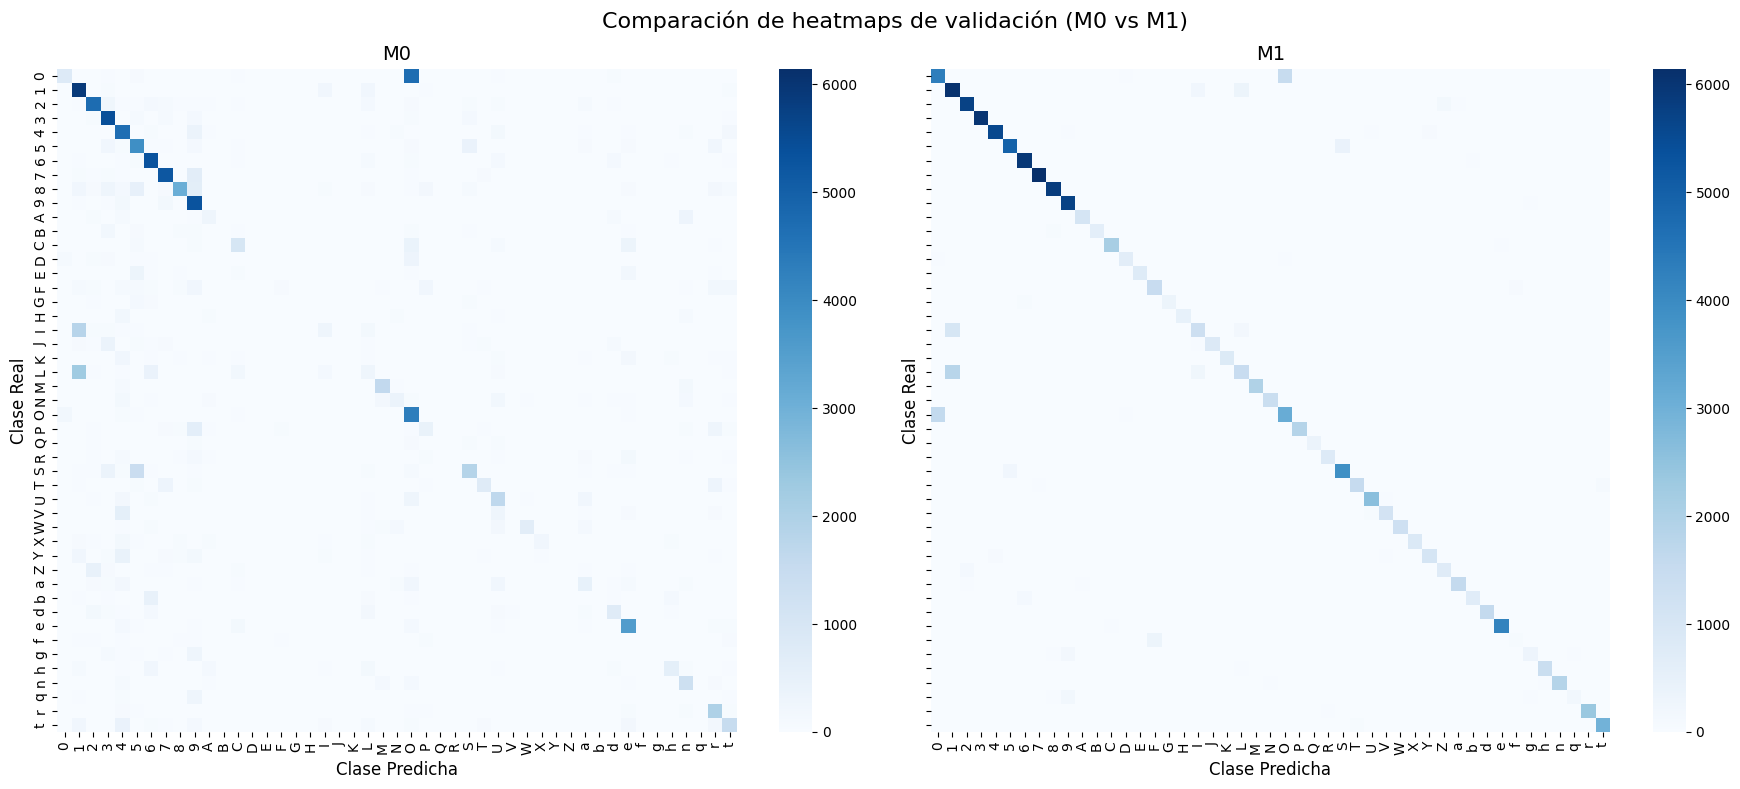

In [34]:
# Resumen comparativo de métricas y heatmaps entre M0 y M1
importlib.reload(metrics)
importlib.reload(utils)
metrics_m1 = metrics.build_metrics_report(
    M1,
    X_train_flat,
    y_train,
    X_val_flat,
    y_val,
    num_classes=47,
    model_name='M1',
)
metrics_m1[['Train', 'Validation']] = metrics_m1[['Train', 'Validation']].round(4)

metrics_m0_val = metrics_m0.set_index('Métrica')['Validation']
metrics_m1_val = metrics_m1.set_index('Métrica')['Validation']
metricas_comparadas = pd.DataFrame({
    'M0': metrics_m0_val,
    'M1': metrics_m1_val,
})
metricas_comparadas['Cambio absoluto'] = metricas_comparadas['M1'] - metricas_comparadas['M0']
metricas_comparadas['Cambio % vs M0'] = 100 * metricas_comparadas['Cambio absoluto'] / metricas_comparadas['M0']
metricas_comparadas = metricas_comparadas.reset_index().rename(columns={'index': 'Métrica'})
metricas_comparadas = metricas_comparadas[['Métrica', 'M0', 'M1', 'Cambio absoluto', 'Cambio % vs M0']]
metricas_comparadas[['M0', 'M1', 'Cambio absoluto']] = metricas_comparadas[['M0', 'M1', 'Cambio absoluto']].round(4)
metricas_comparadas['Cambio % vs M0'] = metricas_comparadas['Cambio % vs M0'].round(2)
display(metricas_comparadas)

pred_val_m0 = metrics.predict(M0, X_val_flat)
pred_val_m1 = metrics.predict(M1, X_val_flat)
cm_val_m0 = metrics.compute_confusion_matrix(y_val, pred_val_m0, num_classes=47)
cm_val_m1 = metrics.compute_confusion_matrix(y_val, pred_val_m1, num_classes=47)

utils.plot_confusion_matrix_comparison(
    cm_val_m0,
    cm_val_m1,
    baseline_label='M0',
    improved_label='M1',
    title='Comparación de heatmaps de validación (M0 vs M1)',
)

## 4. Desarrollo de una Red Neuronal con PyTorch

In [ ]:
# Pasamos las mismas variables y la configuración ganadora M1_config
importlib.reload(pytorch)
M2, train_loss_M2, val_loss_M2 = pytorch.train_pytorch(
    X_train_flat, y_train, X_val_flat, y_val, config=M1_config, epochs=100
)

Corriendo en: cuda

Iniciando el entrenamiento de M2...
Época 000 | Train Loss: 1.0167 | Val Loss: 0.9391
Época 005 | Train Loss: 0.8445 | Val Loss: 0.8463
Época 010 | Train Loss: 0.8348 | Val Loss: 0.8371
Época 015 | Train Loss: 0.8283 | Val Loss: 0.8305
Época 020 | Train Loss: 0.8240 | Val Loss: 0.8297
Época 025 | Train Loss: 0.8210 | Val Loss: 0.8218
Época 030 | Train Loss: 0.8183 | Val Loss: 0.8214
Época 035 | Train Loss: 0.8162 | Val Loss: 0.8202
Época 040 | Train Loss: 0.8148 | Val Loss: 0.8170
Época 045 | Train Loss: 0.8133 | Val Loss: 0.8175
Época 050 | Train Loss: 0.8124 | Val Loss: 0.8155
¡Early stopping activado en la época 52!


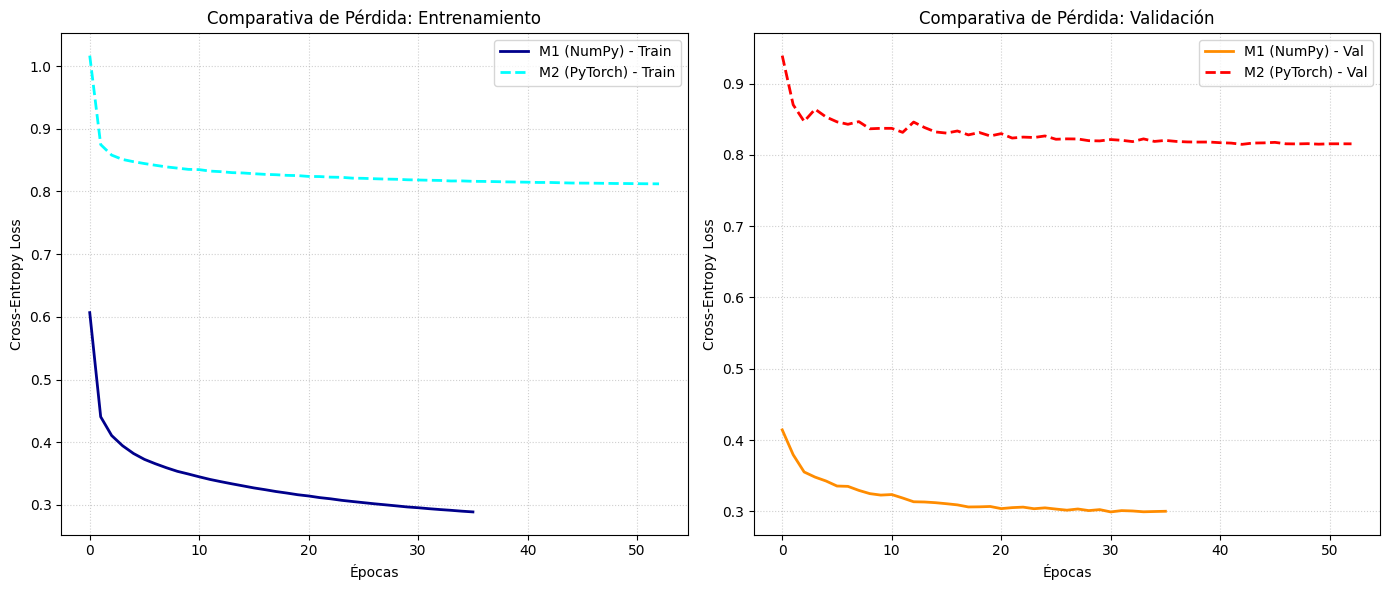


VEREDICTO DE COMPARACIÓN DE PERFORMANCE
M1 (NumPy)   -> Pérdida Mínima en Validación: 0.2994
M2 (PyTorch) -> Pérdida Mínima en Validación: 0.8147
Diferencia absoluta: 0.51532


In [ ]:
importlib.reload(utils)

utils.plot_numpy_pytorch_loss_comparison(
    train_loss_M1,
    train_loss_M2,
    val_loss_M1,
    val_loss_M2,
    model_1_label='M1 (NumPy)',
    model_2_label='M2 (PyTorch)',
)

In [38]:
M3_config = pytorch.grid_search_pytorch_m3(X_train_flat, y_train, X_val_flat, y_val, M1_config)

Iniciando búsqueda de M3 con 18 combinaciones (GPU habilitada si existe)...

[1/18] Probando: Arq=[784, 256, 128, 47], Act=leaky_relu, Drop=0.1

Iniciando el entrenamiento de M2...
Época 000 | Train Loss: 1.0167 | Val Loss: 0.8904
Época 005 | Train Loss: 0.8417 | Val Loss: 0.8475
Época 010 | Train Loss: 0.8313 | Val Loss: 0.8340
Época 015 | Train Loss: 0.8252 | Val Loss: 0.8279
Época 020 | Train Loss: 0.8208 | Val Loss: 0.8253
Época 025 | Train Loss: 0.8177 | Val Loss: 0.8219
Época 030 | Train Loss: 0.8153 | Val Loss: 0.8183
Época 035 | Train Loss: 0.8133 | Val Loss: 0.8146
Época 039 | Train Loss: 0.8118 | Val Loss: 0.8153
--> Val Loss: 0.8139 | Tiempo: 496.0s
⭐ ¡NUEVO MEJOR MODELO (M3)!

[2/18] Probando: Arq=[784, 256, 128, 47], Act=leaky_relu, Drop=0.3

Iniciando el entrenamiento de M2...
Época 000 | Train Loss: 1.0175 | Val Loss: 0.8931
Época 005 | Train Loss: 0.8413 | Val Loss: 0.8415
Época 010 | Train Loss: 0.8310 | Val Loss: 0.8311
Época 015 | Train Loss: 0.8249 | Val Loss: 0.832

In [ ]:
M3, train_loss_M3, val_loss_M3 = pytorch.train_pytorch(
    X_train_flat, y_train, X_val_flat, y_val, config=M3_config, epochs=100
)


Iniciando el entrenamiento de M2...
Época 000 | Train Loss: 1.0069 | Val Loss: 0.8603
Época 005 | Train Loss: 0.7763 | Val Loss: 0.7678
Época 010 | Train Loss: 0.7618 | Val Loss: 0.7663
Época 015 | Train Loss: 0.7533 | Val Loss: 0.7598
Época 020 | Train Loss: 0.7463 | Val Loss: 0.7501
Época 025 | Train Loss: 0.7411 | Val Loss: 0.7442
Época 030 | Train Loss: 0.7370 | Val Loss: 0.7401
Época 035 | Train Loss: 0.7338 | Val Loss: 0.7375
Época 040 | Train Loss: 0.7312 | Val Loss: 0.7329
Época 045 | Train Loss: 0.7291 | Val Loss: 0.7334
Época 050 | Train Loss: 0.7278 | Val Loss: 0.7307
Época 055 | Train Loss: 0.7262 | Val Loss: 0.7287
Época 060 | Train Loss: 0.7252 | Val Loss: 0.7282
Época 065 | Train Loss: 0.7243 | Val Loss: 0.7275
Época 070 | Train Loss: 0.7236 | Val Loss: 0.7267
Época 075 | Train Loss: 0.7230 | Val Loss: 0.7267
Época 080 | Train Loss: 0.7226 | Val Loss: 0.7265
Época 085 | Train Loss: 0.7223 | Val Loss: 0.7258
Época 090 | Train Loss: 0.7220 | Val Loss: 0.7256
Época 095 | T

Evaluando modelos en el conjunto de TEST...

--- RESULTADOS FINALES SOBRE CONJUNTO DE TEST ---
          Modelo  Accuracy  F1-Score Macro
 M0 (Base Numpy)  0.562618        0.336743
  M1 (Top Numpy)  0.893333        0.869450
M2 (PyTorch Eq.)  0.767816        0.651982
M3 (Top PyTorch)  0.787325        0.684382


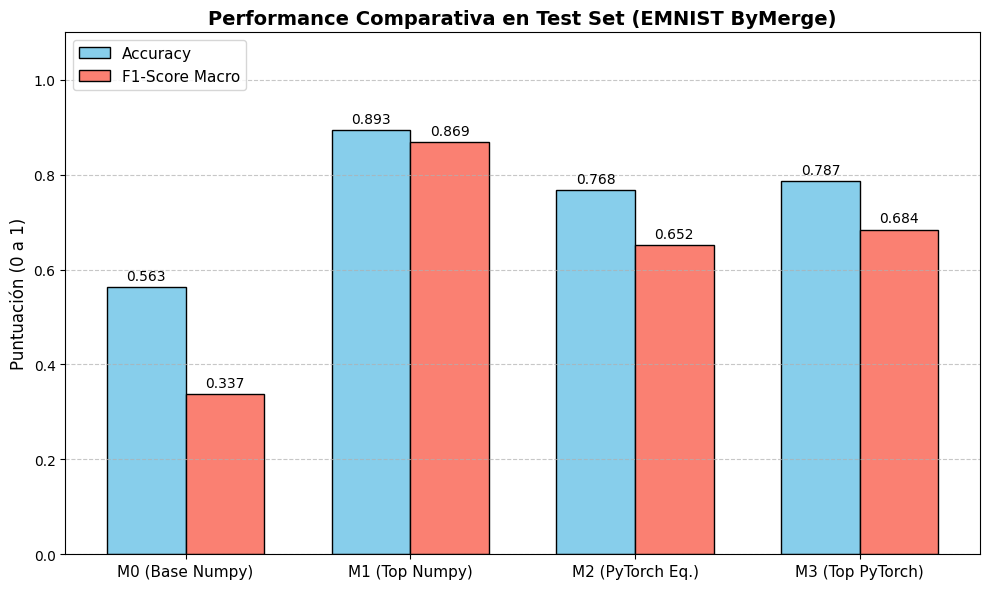

In [ ]:
importlib.reload(pytorch)
importlib.reload(utils)

print("Evaluando modelos en el conjunto de TEST...")

acc_m0, f1_m0 = pytorch.evaluate_model_numpy(M0, X_test_flat, y_test)

acc_m1, f1_m1 = pytorch.evaluate_model_numpy(M1, X_test_flat, y_test)

acc_m2, f1_m2 = pytorch.evaluate_model_pytorch(M2, X_test_flat, y_test)

acc_m3, f1_m3 = pytorch.evaluate_model_pytorch(M3, X_test_flat, y_test)

resultados = {
    'Modelo': ['M0 (Base)', 'M1 (Avanzado)', 'M2 (PyTorch)', 'M3 (PyTorch)'],
    'Accuracy': [acc_m0, acc_m1, acc_m2, acc_m3],
    'F1-Score Macro': [f1_m0, f1_m1, f1_m2, f1_m3]
}

df_resultados = pd.DataFrame(resultados)
print("\n--- RESULTADOS FINALES SOBRE CONJUNTO DE TEST ---")
print(df_resultados.to_string(index=False))

utils.plot_metrics_bar_comparison(
    df_resultados,
    title='Performance Comparativa en Test Set',
    figsize=(10, 6),
)

<>:84: SyntaxWarning: invalid escape sequence '\s'
<>:84: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_19112/1001596786.py:84: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel('Nivel de Ruido (Desviación Estándar $\sigma$)', fontsize=12)


Iniciando prueba de estrés por ruido...
Evaluando con nivel de ruido: 0.0...
Evaluando con nivel de ruido: 0.1...
Evaluando con nivel de ruido: 0.2...
Evaluando con nivel de ruido: 0.3...
Evaluando con nivel de ruido: 0.4...
Evaluando con nivel de ruido: 0.5...
¡Prueba finalizada!


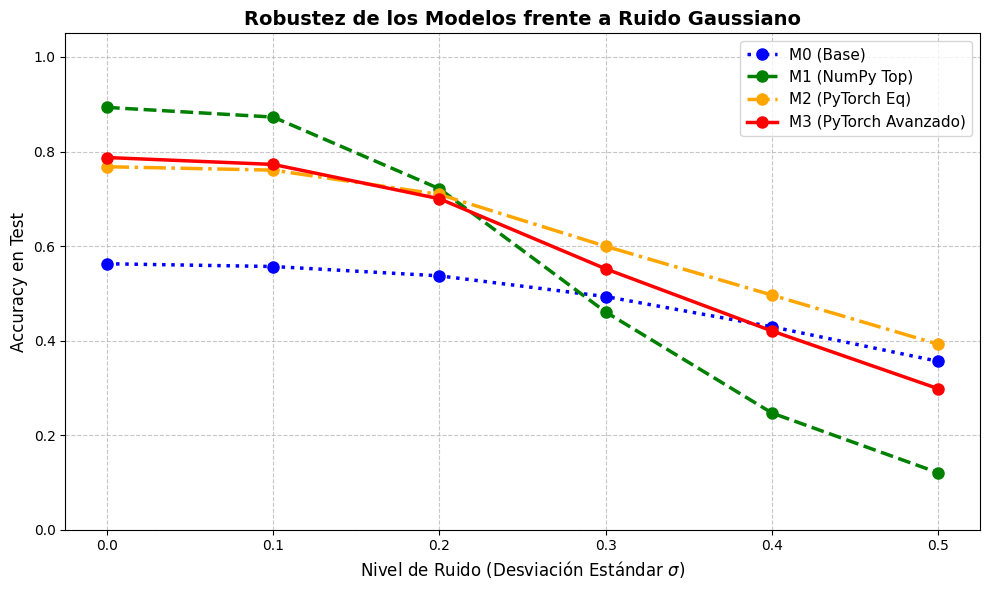

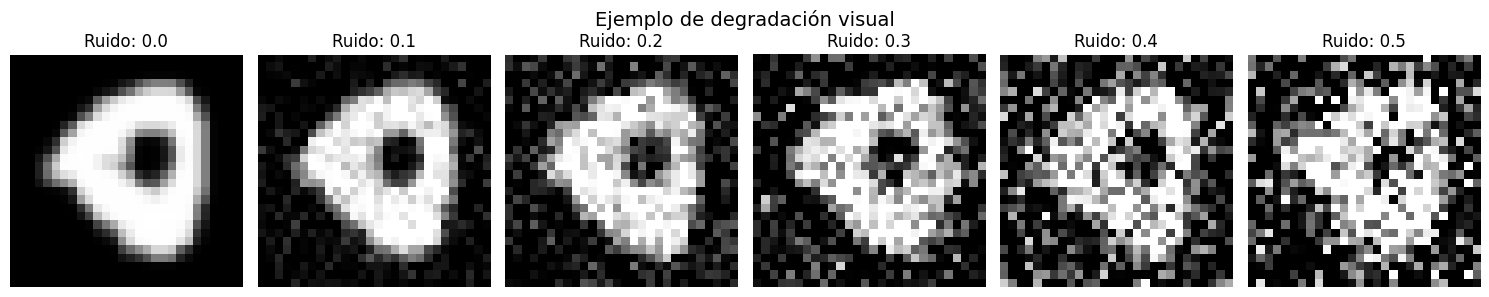

In [ ]:
importlib.reload(utils)

noise = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]

acc_history = {
    'M0 (Base)': [],
    'M1 (Avanzado)': [],
    'M2 (PyTorch)': [],
    'M3 (PyTorch Avanzado)': []
}

for nl in noise:
    
    X_test_noisy = utils.apply_gaussian_noise(X_test_flat, nl)
    
    acc0, _ = pytorch.evaluate_model_numpy(M0, X_test_noisy, y_test)
    acc1, _ = pytorch.evaluate_model_numpy(M1, X_test_noisy, y_test)
    acc2, _ = pytorch.evaluate_model_pytorch(M2, X_test_noisy, y_test)
    acc3, _ = pytorch.evaluate_model_pytorch(M3, X_test_noisy, y_test)
    
    acc_history['M0 (Base)'].append(acc0)
    acc_history['M1 (Avanzado)'].append(acc1)
    acc_history['M2 (PyTorch)'].append(acc2)
    acc_history['M3 (PyTorch Avanzado)'].append(acc3)

utils.plot_noise_robustness(
    acc_history=acc_history,
    niveles_ruido=noise,
    X_test_flat=X_test_flat,
    apply_noise_fn=utils.apply_gaussian_noise,
    title='Robustez de los Modelos frente a Ruido Gaussiano',
    sample_title='Ejemplo de degradación visual',
    x_label=r'Nivel de Ruido (Desviación Estándar $\sigma$)',
)